# **1- INTRODUCTION**

# 🎮 Gaming & Mental Health Data Analysis

**Team:** The Outliers  
**Members:** Mohamed Bedier, Belal, Shahd, Youssef Talaat, Ibrahim  
**Supervised by:** 💌Dr. Amal Mahmoud 💌

---

### 📌 Project Introduction
This project performs an advanced data analysis lifecycle on a comprehensive dataset mapping the intersection between video gaming habits and human psychological, behavioral, and physical well-being. The core mission is to unveil empirical evidence on how intensive gaming correlates with physical strain, sleep architecture, academic/professional productivity, and potential addiction risks.

---

### 📊 Dataset Overview & Star Schema Architecture
The data has been engineered from a flat structure into an optimized **Star Schema Relational Database Engine**, separating descriptive attributes into specialized Dimensions linked to a central Fact Table.

#### 1. 🔲 Central Fact Table
* **`Fact_Gaming_Mental_Health`**: Holds quantitative metrics and keys.
  * **Keys:** `record_id` (PK), `Addiction_Id` (FK), `Physical_Id` (FK), `Sleep_Id` (FK), `Game_Id` (FK), `Platform_Id` (FK)
  * **Metrics & Measures:** `daily_gaming_hours`, `Gaming_Hours_Category`, `sleep_hours`, `academic_work_performance`, `grades_gpa`, `work_productivity_score`, `mood_state`, `mood_swing_frequency`, `weight_change_kg`, `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`, `monthly_game_spending_usd`, `years_gaming`, `Total_spent`, `Spend_Category`

#### 2. 🔷 Dimension Tables
* **`Dim_Platform`**: `Platform_Id` (PK), `gaming_platform`
* **`Dim_Game`**: `Game_Id` (PK), `game_genre`, `primary_game`
* **`Dim_Player`**: `record_id` (PK), `age`, `Age_Group`, `gender`, `Educational_State`
* **`Dim_Sleep`**: `Sleep_Id` (PK), `sleep_quality`, `sleep_disruption_frequency`, `Sleep_State`
* **`Dim_Addiction`**: `Addiction_Id` (PK), `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`, `gaming_addiction_risk_level`
* **`Dim_PhysicalStatus`**: `Physical_Id` (PK), `eye_strain`, `back_neck_pain`, `Physical_Pain`

---

### 🛠️ End-to-End Pipeline Roadmap
Our execution map covers the fundamental phases of professional data analytics:

* ✅ **Data Quality Check:** Validated empty cells and handled missing entries dynamically by transforming text blanks into appropriate database `NULL` markers (e.g., `grades_gpa` & `work_productivity_score`).
* ✅ **Statistical Outlier Validation:** Enforced formal empirical checks leveraging the Standard Normal Distribution criteria ($\mu \pm 3\sigma$) to verify data purity.
* ✅ **Feature Engineering:** Expanded structural depth by computing complex behavioral dimensions such as `Total_spent`, statistical `Spend_Category`, `sleep_states`, `Educational_State`, `Physical_Pain` indexes, and custom `Gaming_Hours_Category`.
* ✅ **Data Modeling & ETL:** Designed the relational database architecture and executed ordered insert sequences populating the dimensional nodes before generating the fact connections.
* ✅ **Exploratory Data Analysis (EDA):** Queried cross-dimensional behavior using complex relational SQL aggregations (`GROUP BY`, `JOIN`, `Subqueries`).
* 🔄 **Data Visualization & Storytelling:** Connecting Python environments directly to the database via `SQLAlchemy`, using `Pandas`, `Matplotlib`, and `Seaborn` to reveal high-impact strategic insights.

# **2- IMPORT LIBRARIES**

In [185]:
# data manipulation ibraries
import pandas as pd
import numpy as np

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


# **3- LOADING DATASET**

In [186]:
df = pd.read_csv(r"D:\Courses\DEPI\kaggle\002 - Gaming & Mental Health\Gaming and Mental Health.csv")

# **4- BASIC INFORMATION ABOUT DATASET**

In [187]:
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [188]:
print(df.shape)

(1000, 27)


In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [190]:
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [191]:
df.tail()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low
999,GD1000,29,Male,3.5,RPG,Cyberpunk 2077,Multi-platform,7.4,Good,Sometimes,...,False,False,False,0.0,9.3,2,10.9,25.20,19,Low


# **5- Descriptive Statistics of Numeric Variables**

In [192]:
mean = df["daily_gaming_hours"].mean()
std = df["daily_gaming_hours"].std()

lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

outliers_df = df[(df["daily_gaming_hours"] < lower_bound) | (df["daily_gaming_hours"] > upper_bound)]

print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Total Outliers Found : {len(outliers_df)}")

print("\n------------------------------------------------\n")

if not outliers_df.empty:
    display(outliers_df)
else:
    print("\nNo outliers found")


Lower Bound : -2.45
Upper Bound : 14.75
Total Outliers Found : 2

------------------------------------------------



,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
69,GD0070,18,Female,15.1,MMO,World of Warcraft,PC,4.8,Fair,Often,...,False,True,True,0.0,4.2,10,0.0,209.75,6,High
258,GD0259,15,Male,15.1,Strategy,Age of Empires,Multi-platform,5.7,Fair,Sometimes,...,False,True,True,1.5,0.7,9,0.0,435.38,2,Moderate


In [193]:
# --- Quick outlier check ---
# Using the 3-standard-deviation rule: values outside (mean ± 3*std) are flagged

numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}--> {len(outliers)} outliers found")

age--> 16 outliers found
daily_gaming_hours--> 2 outliers found
sleep_hours--> 0 outliers found
grades_gpa--> 0 outliers found
work_productivity_score--> 0 outliers found
weight_change_kg--> 17 outliers found
exercise_hours_weekly--> 2 outliers found
social_isolation_score--> 0 outliers found
face_to_face_social_hours_weekly--> 0 outliers found
monthly_game_spending_usd--> 21 outliers found
years_gaming--> 11 outliers found


# **6- Exploratory Data Analysis**

In [194]:
df.isnull().sum()

record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [195]:
duplicates = df["record_id"].duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 0


# **7- Data Prepossessing (FEATURE ENGINEERING)** 

#### 7.1 age_group

In [196]:
# Classify each player into an age bracket for demographic grouping
df["age_group"] = df["age"].apply(
    lambda age: "Teenager"    if age <= 18 else
                "Young_Adult" if age <= 28 else
                "Adult"
)

In [197]:
df[["age", "age_group"]]

,age,age_group
0,17,Teenager
1,21,Young_Adult
2,23,Young_Adult
3,20,Young_Adult
4,18,Teenager
...,...,...
995,15,Teenager
996,18,Teenager
997,23,Young_Adult
998,18,Teenager


#### 7.2 educational_state

In [415]:
# Classify players based on which performance metric they have:
# grades_gpa  → Student
# work_productivity_score → Worker
# both → Working_Student
# neither → Unknown
df["educational_state"] = df.apply(
    lambda row:
        "Working_Student" if pd.notna(row["grades_gpa"]) and pd.notna(row["work_productivity_score"]) else
        "Student"         if pd.notna(row["grades_gpa"]) else
        "Worker"          if pd.notna(row["work_productivity_score"]) else
        "Unknown",
    axis=1
)

In [199]:
df[["educational_state", "grades_gpa","work_productivity_score"]]

,educational_state,grades_gpa,work_productivity_score
0,Student,1.25,NaN
1,Working_Student,3.75,2.0
2,Worker,NaN,9.0
3,Working_Student,1.62,2.0
4,Student,2.44,NaN
...,...,...,...
995,Student,2.96,NaN
996,Student,3.42,NaN
997,Worker,NaN,3.0
998,Student,1.03,NaN


#### 7.3 sleep_state

In [200]:
# Label each player's sleep duration as Poor / Healthy / over_sleep
df["sleep_state"] = df["sleep_hours"].apply(
    lambda h: "Poor"       if h <= 4 else
              "Healthy"    if h <= 8 else
              "over_sleep"
)

In [201]:
df[["sleep_state", "sleep_hours"]]

,sleep_state,sleep_hours
0,Poor,3.7
1,Healthy,7.2
2,Healthy,4.4
3,Healthy,5.1
4,Poor,3.4
...,...,...
995,Healthy,4.1
996,Healthy,6.5
997,Poor,3.9
998,over_sleep,8.2


#### 7.4 gaming_hours_category

In [202]:
# Bucket daily gaming hours using mean ± std thresholds
# (same logic used later for spending — avoids hard-coded cutoffs)
avg_gaming_hours = df["daily_gaming_hours"].mean()
std_gaming_hours = df["daily_gaming_hours"].std()
 
df["gaming_hours_category"] = df["daily_gaming_hours"].apply(
    lambda h: "Low"       if h < avg_gaming_hours else
              "Medium"    if h <= avg_gaming_hours + std_gaming_hours else
              "High"      if h <= avg_gaming_hours + 2 * std_gaming_hours else
              "Very High"
)

In [203]:
df[["gaming_hours_category", "daily_gaming_hours"]]

,gaming_hours_category,daily_gaming_hours
0,High,11.1
1,Low,3.0
2,Medium,7.6
3,Medium,7.2
4,Medium,6.8
...,...,...
995,Medium,8.6
996,Low,5.4
997,Medium,7.3
998,Low,3.1


#### 7.5 total_spent

In [204]:
# Estimate lifetime spending: monthly spend × 12 months × years gaming
df["total_spent"] = (df["monthly_game_spending_usd"] * 12 * df["years_gaming"]).round(2)

In [205]:
df[["total_spent", "monthly_game_spending_usd","years_gaming"]]

,total_spent,monthly_game_spending_usd,years_gaming
0,13813.20,383.70,3
1,559.68,46.64,1
2,7258.32,100.81,6
3,4334.40,51.60,7
4,390.84,32.57,1
...,...,...,...
995,15355.44,426.54,3
996,7031.64,83.71,7
997,5316.00,88.60,5
998,2113.92,22.02,8


#### 7.6 Spend_Category

In [206]:
# Bucket players into spend tiers using the same mean/std approach
avg_spent = df["total_spent"].mean()
std_spent = df["total_spent"].std()
 
df["Spend_Category"] = df["total_spent"].apply(
    lambda s: "Low"       if s <= avg_spent else
              "Mid"       if s <= avg_spent + std_spent else
              "High"      if s <= avg_spent + 2 * std_spent else
              "Very High"
)

In [207]:
df[['total_spent', 'Spend_Category']]

,total_spent,Spend_Category
0,13813.20,Mid
1,559.68,Low
2,7258.32,Mid
3,4334.40,Low
4,390.84,Low
...,...,...
995,15355.44,Mid
996,7031.64,Low
997,5316.00,Low
998,2113.92,Low


#### 7.7 physical_pain

In [208]:
# Combine eye_strain and back_neck_pain flags into a single risk label:
# Both true  → High_Risk
# One true   → Moderate
# Neither    → Low_Risk
df["physical_pain"] = df.apply(
    lambda row:
        "High_Risk" if row["eye_strain"] and row["back_neck_pain"] else
        "Moderate"  if row["eye_strain"] or  row["back_neck_pain"] else
        "Low_Risk",
    axis=1
)

In [209]:
df[['physical_pain', 'back_neck_pain']]

,physical_pain,back_neck_pain
0,Moderate,False
1,Low_Risk,False
2,Moderate,True
3,High_Risk,True
4,Low_Risk,False
...,...,...
995,High_Risk,True
996,Moderate,False
997,Moderate,True
998,Low_Risk,False


# **8- DATA MODELING (STAR SCHEMA)**

#### 8.1 Dim_Platform

In [210]:
# One row per distinct gaming platform (PC, Console, Mobile, Multi-platform)
dim_platform = (
    df[["gaming_platform"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_platform["platform_id"] = dim_platform.index + 1

In [211]:
dim_platform

,gaming_platform,platform_id
0,PC,1
1,Multi-platform,2
2,Console,3
3,Mobile,4


#### 8.2 Dim_Game

In [212]:
# One row per distinct (genre, game) combination — 24 combos total
dim_game = (
    df[["game_genre", "primary_game"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_game["game_id"] = dim_game.index + 1

In [213]:
dim_game

,game_genre,primary_game,game_id
0,Mobile Games,Clash of Clans,1
1,MOBA,Dota 2,2
2,FPS,CS:GO,3
3,RPG,Skyrim,4
4,Battle Royale,Apex Legends,5
5,FPS,Call of Duty,6
6,Mobile Games,Genshin Impact,7
7,MMO,Final Fantasy XIV,8
8,Strategy,StarCraft II,9
9,RPG,Elden Ring,10


#### 8.3 Dim_Player

In [214]:
# One row per player — record_id is the natural primary key here
dim_player = df[
    ["record_id", "age", "age_group", "gender", "educational_state"]
].copy()

In [215]:
dim_player

,record_id,age,age_group,gender,educational_state
0,GD0001,17,Teenager,Male,Student
1,GD0002,21,Young_Adult,Male,Working_Student
2,GD0003,23,Young_Adult,Male,Worker
3,GD0004,20,Young_Adult,Female,Working_Student
4,GD0005,18,Teenager,Male,Student
...,...,...,...,...,...
995,GD0996,15,Teenager,Female,Student
996,GD0997,18,Teenager,Male,Student
997,GD0998,23,Young_Adult,Male,Worker
998,GD0999,18,Teenager,Male,Student


#### 8.4 Dim_Sleep

In [216]:
# One row per distinct (sleep_quality, sleep_disruption_frequency) pair
dim_sleep = (
    df[["sleep_quality","sleep_disruption_frequency"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_sleep["sleep_id"] = dim_sleep.index + 1

In [217]:
dim_sleep

,sleep_quality,sleep_disruption_frequency,sleep_id
0,Very Poor,Sometimes,1
1,Fair,Rarely,2
2,Fair,Often,3
3,Poor,Never,4
4,Very Poor,Often,5
5,Fair,Sometimes,6
6,Poor,Always,7
7,Insomnia,Often,8
8,Good,Often,9
9,Good,Sometimes,10


#### 8.5 Dim_Addiction

In [218]:
# One row per distinct combination of the three symptom flags + risk level
dim_addiction = (
    df[["withdrawal_symptoms","loss_of_other_interests","continued_despite_problems","gaming_addiction_risk_level"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_addiction["addiction_id"] = dim_addiction.index + 1

In [219]:
dim_addiction

,withdrawal_symptoms,loss_of_other_interests,continued_despite_problems,gaming_addiction_risk_level,addiction_id
0,True,False,True,Severe,1
1,False,False,False,Low,2
2,True,True,True,Severe,3
3,True,True,False,High,4
4,True,False,False,Moderate,5
5,True,False,False,High,6
6,True,True,False,Severe,7
7,False,True,False,Moderate,8
8,True,False,True,High,9
9,False,False,False,Moderate,10


#### 8.6 Dim_Pysical

In [220]:
# One row per distinct (eye_strain, back_neck_pain, physical_pain) combo — 4 combos
dim_physical = (
    df[["eye_strain","back_neck_pain","physical_pain"]]
    .drop_duplicates()
    .reset_index(drop=True)
)
dim_physical["physical_id"] = dim_physical.index + 1

In [221]:
dim_physical

,eye_strain,back_neck_pain,physical_pain,physical_id
0,True,False,Moderate,1
1,False,False,Low_Risk,2
2,False,True,Moderate,3
3,True,True,High_Risk,4


#### 8.7 Fact_Gaming_Mental_Health

In [222]:
# Start from the enriched flat table, then merge in each dim's surrogate key
# so the final fact table holds only IDs (not repeated text attributes)
fact_gaming_mental_health = df.copy()

fact_gaming_mental_health = fact_gaming_mental_health.merge(
    dim_platform,
    on="gaming_platform",
    how="left"
)

fact_gaming_mental_health = fact_gaming_mental_health.merge(
    dim_game,
    on=["game_genre", "primary_game"],
    how="left"
)

fact_gaming_mental_health = fact_gaming_mental_health.merge(
    dim_sleep,
    on=["sleep_quality", "sleep_disruption_frequency"],
    how="left"
)

fact_gaming_mental_health = fact_gaming_mental_health.merge(
    dim_addiction,
    on=[
        "withdrawal_symptoms",
        "loss_of_other_interests",
        "continued_despite_problems",
        "gaming_addiction_risk_level"
    ],
    how="left"
)

fact_gaming_mental_health = fact_gaming_mental_health.merge(
    dim_physical,
    on=[
        "eye_strain",
        "back_neck_pain",
        "physical_pain"
    ],
    how="left"
)

In [223]:
fact_gaming_mental_health

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,sleep_state,gaming_hours_category,total_spent,Spend_Category,physical_pain,platform_id,game_id,sleep_id,addiction_id,physical_id
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,Poor,High,13813.20,Mid,Moderate,1,1,1,1,1
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,Healthy,Low,559.68,Low,Low_Risk,1,2,2,2,2
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,Healthy,Medium,7258.32,Mid,Moderate,2,3,3,3,3
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,Healthy,Medium,4334.40,Low,High_Risk,2,4,3,4,4
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,Poor,Medium,390.84,Low,Low_Risk,1,5,4,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,Healthy,Medium,15355.44,Mid,High_Risk,1,21,15,1,4
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,Healthy,Low,7031.64,Low,Moderate,2,19,12,2,1
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,Poor,Medium,5316.00,Low,Moderate,1,4,21,4,3
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,over_sleep,Low,2113.92,Low,Low_Risk,3,9,6,2,2


In [224]:
# Select only the columns that belong in the final fact table:
# record_id + FK columns + measure columns
fact_table = fact_gaming_mental_health[[
    "record_id",
 
    # Foreign Keys (point to dimension tables)
    "platform_id",
    "game_id",
    "sleep_id",
    "addiction_id",
    "physical_id",
 
    # Gaming measures
    "daily_gaming_hours",
    "gaming_hours_category",
    "years_gaming",
 
    # Spending measures
    "monthly_game_spending_usd",
    "total_spent",
    "Spend_Category",
 
    # Sleep measures
    "sleep_hours",
    "sleep_state",
 
    # Health & wellbeing measures
    "weight_change_kg",
    "exercise_hours_weekly",
    "social_isolation_score",
    "face_to_face_social_hours_weekly",
 
    # Academic / productivity measures
    "academic_work_performance",
    "grades_gpa",
    "work_productivity_score",
 
    # Mood measures
    "mood_state",
    "mood_swing_frequency",
]]

In [225]:
fact_table

,record_id,platform_id,game_id,sleep_id,addiction_id,physical_id,daily_gaming_hours,gaming_hours_category,years_gaming,monthly_game_spending_usd,...,sleep_state,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,academic_work_performance,grades_gpa,work_productivity_score,mood_state,mood_swing_frequency
0,GD0001,1,1,1,1,1,11.1,High,3,383.70,...,Poor,6.8,3.7,7,1.3,Below Average,1.25,NaN,Anxious,Never
1,GD0002,1,2,2,2,2,3.0,Low,1,46.64,...,Healthy,0.4,8.5,2,10.7,Good,3.75,2.0,Irritable,Often
2,GD0003,2,3,3,3,3,7.6,Medium,6,100.81,...,Healthy,1.8,7.1,5,3.2,Poor,NaN,9.0,Irritable,Rarely
3,GD0004,2,4,3,4,4,7.2,Medium,7,51.60,...,Healthy,0.2,5.2,4,9.1,Poor,1.62,2.0,Withdrawn,Daily
4,GD0005,1,5,4,5,2,6.8,Medium,1,32.57,...,Poor,0.5,6.1,4,4.5,Average,2.44,NaN,Angry,Daily
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,GD0996,1,21,15,1,4,8.6,Medium,3,426.54,...,Healthy,1.9,7.5,6,2.4,Average,2.96,NaN,Restless,Sometimes
996,GD0997,2,19,12,2,1,5.4,Low,7,83.71,...,Healthy,2.1,7.7,1,10.9,Excellent,3.42,NaN,Angry,Often
997,GD0998,1,4,21,4,3,7.3,Medium,5,88.60,...,Poor,0.5,8.1,5,6.7,Poor,NaN,3.0,Withdrawn,Daily
998,GD0999,3,9,6,2,2,3.1,Low,8,22.02,...,over_sleep,0.8,8.4,1,12.7,Good,1.03,NaN,Normal,Rarely


# **9- Diagram for Data Modeling**

![Star Schema](Data_Modeling.png)

# **10- KPIs**

In [226]:
kpis = pd.DataFrame({
    "total_players": [len(fact_gaming_mental_health)],
    "avg_daily_gaming_hours": [fact_gaming_mental_health["daily_gaming_hours"].mean().round(1)],
    "avg_sleep_hours": [fact_gaming_mental_health["sleep_hours"].mean().round(1)],
    "avg_social_isolation": [fact_gaming_mental_health["social_isolation_score"].mean().round(1)],
    "avg_monthly_spending": [fact_gaming_mental_health["monthly_game_spending_usd"].mean().round(1)],
    "total_spending": [fact_gaming_mental_health["total_spent"].sum().round(1)]
})

kpis

,total_players,avg_daily_gaming_hours,avg_sleep_hours,avg_social_isolation,avg_monthly_spending,total_spending
0,1000,6.2,5.7,3.9,105.2,7204598.5


# **11- Data Analysis**

#### **11.1 Gender Analysis**

In [357]:
gender_analysis = (
    fact_table.merge(dim_player, on ="record_id" ,how="inner")
    .groupby("gender")
    .agg(
        count_gender = ("record_id","count")
    )
    .reset_index()
)

gender_analysis

,gender,count_gender
0,Female,331
1,Male,647
2,Other,22


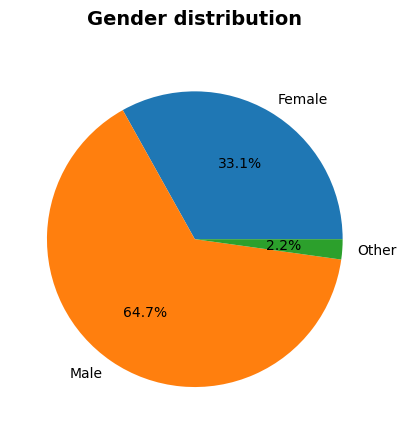

In [361]:
plt.pie(
    x=gender_analysis["count_gender"],       
    labels=gender_analysis["gender"], 
    autopct='%1.1f%%'
)

plt.title("Gender distribution\n", fontsize=14, fontweight='bold')
plt.show()

#### **11.2 Age Group Analysis**

In [364]:
age_group_analysis = (
    fact_table.merge(dim_player, on ="record_id" ,how="inner")
    .groupby("age_group")
    .agg(
        avg_gaming_hours=("daily_gaming_hours", "mean"),
    )
    .reset_index()
)

age_group_analysis

,age_group,avg_gaming_hours
0,Adult,5.558000
1,Teenager,6.117791
2,Young_Adult,6.216506


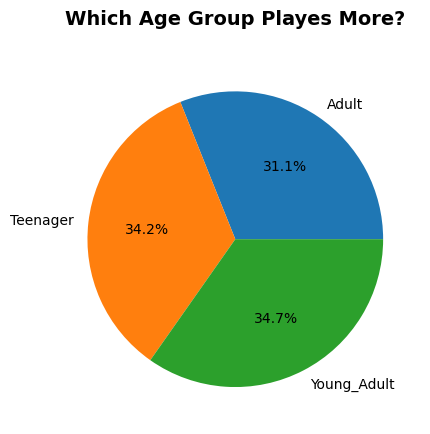

In [366]:
plt.pie(
    x=age_group_analysis["avg_gaming_hours"],       
    labels=age_group_analysis["age_group"], 
    autopct='%1.1f%%'
)

plt.title("Which Age Group Playes More?\n", fontsize=14, fontweight='bold')
plt.show()

#### **11.3 Mood Analysis**

In [382]:
mood_analysis = (
    fact_table.groupby("mood_state")
    .agg(
        avg_spend = ("total_spent","mean")
    )
    .reset_index()
    .sort_values(by="avg_spend", ascending =True)
    .round(1)
)
mood_analysis

,mood_state,avg_spend
4,Excited,3109.2
6,Normal,4529.9
3,Euphoric,5929.0
0,Angry,6447.9
8,Withdrawn,6568.8
7,Restless,6948.9
2,Depressed,7321.0
5,Irritable,9766.9
1,Anxious,10225.7


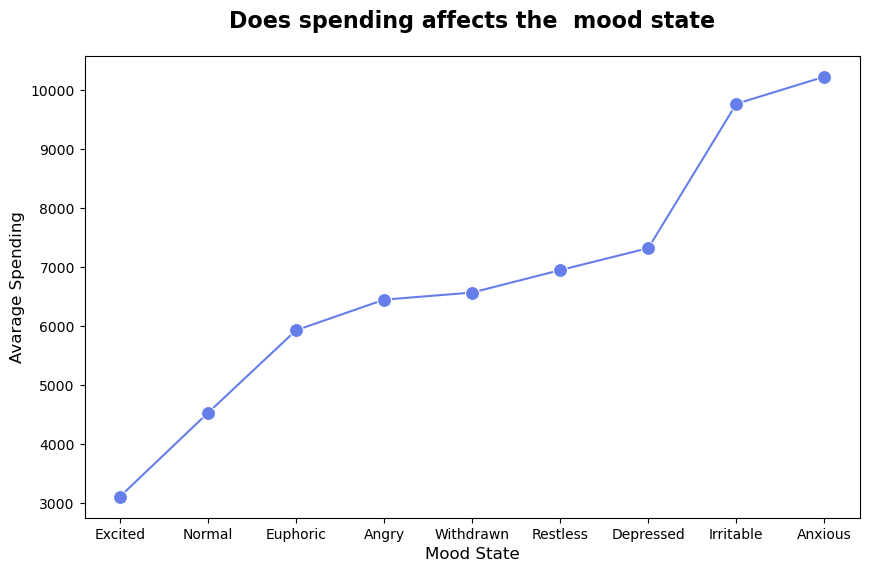

In [383]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mood_analysis,
    x='mood_state', 
    y='avg_spend', 
   marker='o',markersize=10, color='#667eea'
)

plt.title('Does spending affects the  mood state', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mood State', fontsize=12)
plt.ylabel('Avarage Spending', fontsize=12)
plt.show()

#### **11.4 Addiction Analysis**

In [277]:
addiction_analysis = (
    fact_table.merge(dim_addiction, on="addiction_id", how="inner")
    .groupby("gaming_addiction_risk_level")
    .agg(
        players=("record_id", "count"),
        avg_gaming_hours=("daily_gaming_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
    .round(1)
)

addiction_analysis

,gaming_addiction_risk_level,players,avg_gaming_hours,avg_social_isolation,avg_spending
0,High,154,8.7,5.5,157.6
1,Low,514,4.0,2.5,48.0
2,Moderate,190,7.0,4.3,102.7
3,Severe,142,10.0,6.5,258.9


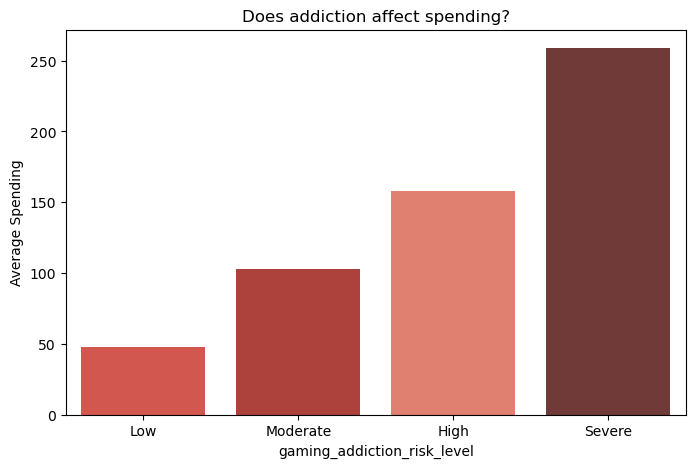

In [287]:
plt.figure(figsize=(8, 5))
# my_own_order = 


sns.barplot(
    data=addiction_analysis, 
    x="gaming_addiction_risk_level", 
    y="avg_spending",
    order=["Low", "Moderate", "High", "Severe"] ,
    palette="Reds_d",
    hue="gaming_addiction_risk_level"
)

plt.title("Does addiction affect spending?")
plt.ylabel("Average Spending")
plt.show()

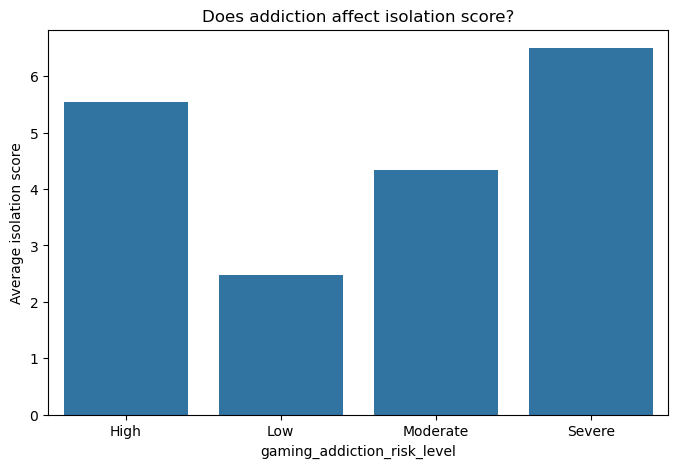

In [229]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=addiction_analysis, 
    x="gaming_addiction_risk_level", 
    y="avg_social_isolation"        
)

plt.title("Does addiction affect isolation score?")
plt.ylabel("Average isolation score")
plt.show()

#### **11.5 Sleep Analysis**

In [307]:
gaming_sleep_analysis = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_state")
    .agg(
        players=("record_id", "count"),
        avg_exercise_hours=("exercise_hours_weekly", "mean"),
    )
    .reset_index()
    .sort_values(by="avg_exercise_hours", ascending=True) 
)

gaming_sleep_analysis

,sleep_state,players,avg_exercise_hours
1,Poor,147,5.800000
0,Healthy,764,6.935864
2,over_sleep,89,8.924719


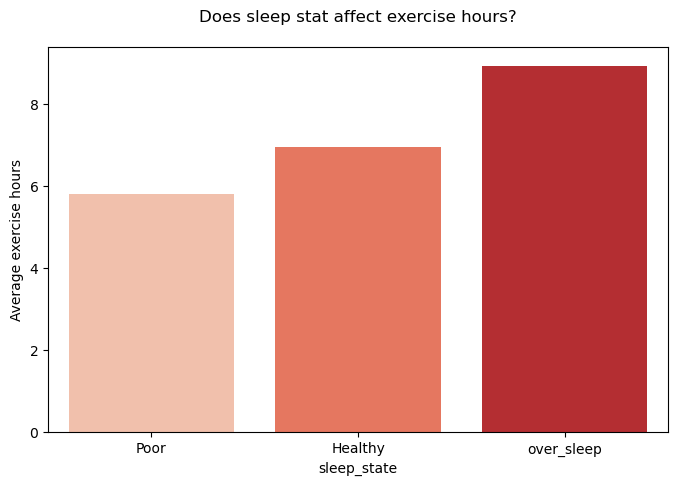

In [309]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gaming_sleep_analysis, 
    x="sleep_state", 
    y="avg_exercise_hours",
    palette="Reds",
    hue="sleep_state"
)

plt.title("Does sleep stat affect exercise hours?\n")
plt.ylabel("Average exercise hours")
plt.show()

In [310]:
gaming_sleep_analysis2 = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_quality")
    .agg(
        avg_daily_hours=("daily_gaming_hours", "mean")
    )
    .reset_index()
    .sort_values(by="avg_daily_hours", ascending=True) 
)

gaming_sleep_analysis2

,sleep_quality,avg_daily_hours
1,Good,4.049057
0,Fair,5.433447
3,Poor,6.937456
4,Very Poor,8.100571
2,Insomnia,8.651351


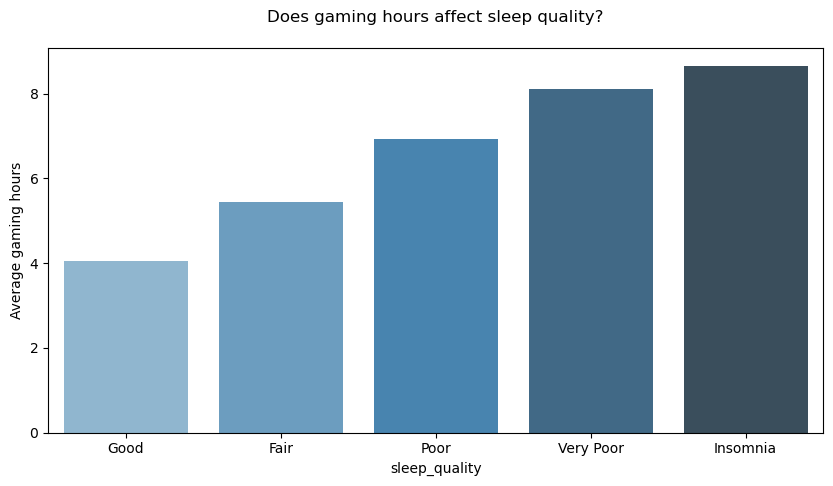

In [311]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=gaming_sleep_analysis2, 
    x="sleep_quality", 
    y="avg_daily_hours",
    palette = "Blues_d",
    hue="sleep_quality"
)

plt.title("Does gaming hours affect sleep quality?\n")
plt.ylabel("Average gaming hours")
plt.show()

#### **11.6 Platform Analysis**

In [326]:
platform_analysis = (
    fact_table.merge(dim_platform, on="platform_id", how="inner")
    .groupby("gaming_platform")
    .agg(
        players=("record_id", "count"),
        avg_gaming_hours=("daily_gaming_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
)

platform_analysis

,gaming_platform,players,avg_gaming_hours,avg_social_isolation,avg_spending
0,Console,237,6.331224,3.995781,109.689241
1,Mobile,262,5.906107,3.721374,97.310000
2,Multi-platform,260,6.268846,3.911538,106.629231
3,PC,241,6.114523,3.871369,107.902739


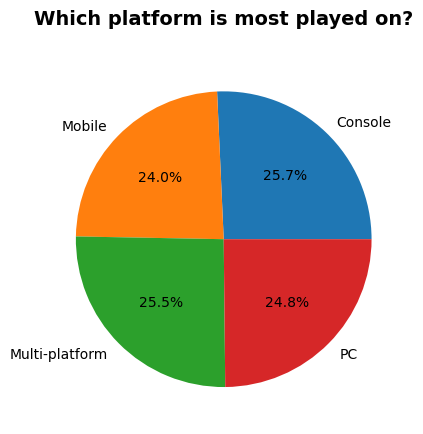

In [327]:
plt.pie(
    x=platform_analysis["avg_gaming_hours"],       
    labels=platform_analysis["gaming_platform"], 
    autopct='%1.1f%%'
)

plt.title("Which platform is most played on?\n", fontsize=14, fontweight='bold')
plt.show()

gaming_addiction_risk_level  High  Low  Moderate  Severe
gaming_platform                                         
Console                        44  109        46      38
Mobile                         44  135        53      30
Multi-platform                 36  135        48      41
PC                             30  135        43      33


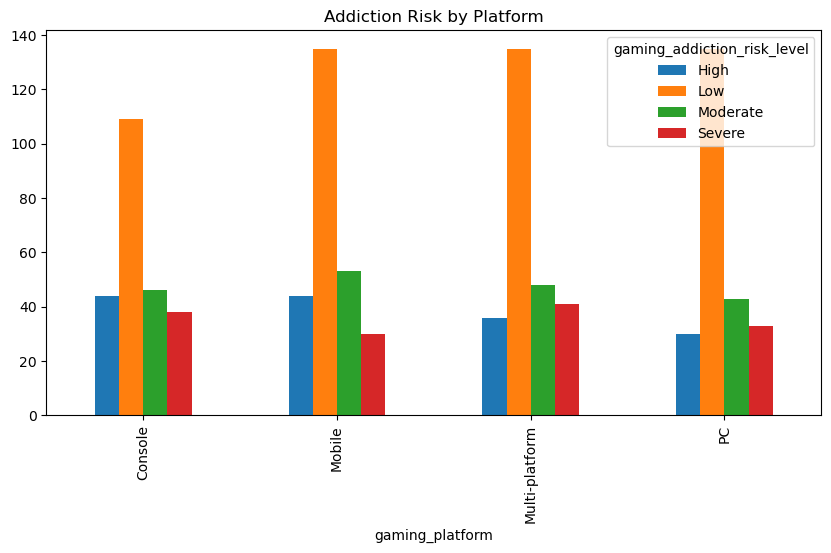

In [339]:
platform_risk = pd.crosstab(
    fact_gaming_mental_health["gaming_platform"],
    fact_gaming_mental_health["gaming_addiction_risk_level"]
)

print(platform_risk)

platform_risk.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Addiction Risk by Platform")
plt.show()

#### **11.7 Age Analysis**

In [416]:
age_analysis = (
    fact_table.merge(dim_player, on="record_id", how="inner")
   .groupby("age_group")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean")
    )
    .reset_index()
)

age_analysis

,age_group,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation
0,Adult,50,5.558000,6.004000,3.540000
1,Teenager,326,6.117791,5.739877,3.769939
2,Young_Adult,624,6.216506,5.715865,3.951923


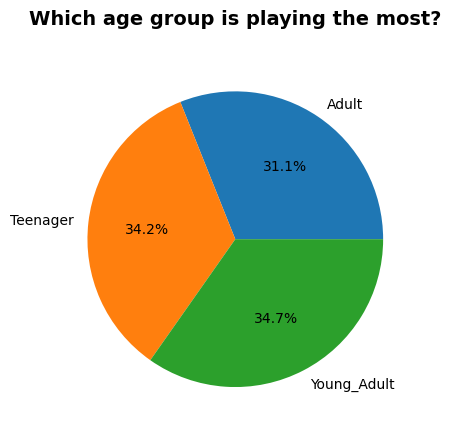

In [330]:
plt.pie(
    x=age_analysis["sum_gaming_hours"],       
    labels=age_analysis["age_group"], 
    autopct='%1.1f%%'
)

plt.title("Which age group is playing the most?\n", fontsize=14, fontweight='bold')
plt.show()

#### **11.8 Game Genre Analysis**

In [334]:
genre_addiction = (
    fact_table.merge(dim_game, on="game_id", how="inner")
    .groupby("game_genre")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        total_spending=("monthly_game_spending_usd", "sum")
    )
    .reset_index()
    .sort_values(by="total_spending", ascending=False)
)
genre_addiction

,game_genre,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation,total_spending
3,MOBA,156,5.962179,5.791026,3.653846,17021.29
2,MMO,143,6.222378,5.774126,3.944056,16368.79
6,Strategy,141,6.366667,5.575177,3.943262,16238.25
5,RPG,146,6.130137,5.640411,4.020548,15607.52
0,Battle Royale,141,6.304965,5.758865,3.957447,13840.60
4,Mobile Games,139,6.233094,5.706475,3.884892,13583.12
1,FPS,134,5.846269,5.926866,3.708955,12560.16


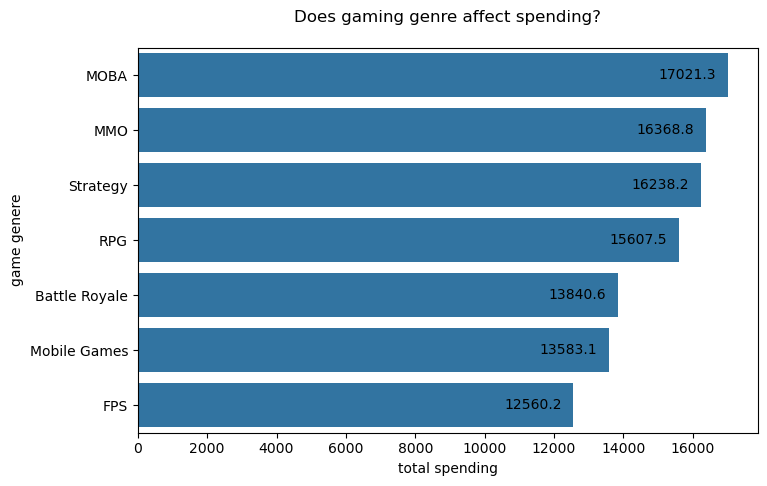

In [335]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=sorted_genres, 
    x="total_spending",
    y="game_genre"
)


for container in ax.containers:
    ax.bar_label(
        container, 
        padding=-50,           
    )

plt.title("Does gaming genre affect spending?\n")
plt.xlabel("total spending")
plt.ylabel("game genere")
plt.show()

#### **11.9 Spending Analysis**

In [337]:
spending_analysis = (
    fact_table.groupby("Spend_Category")
    .agg(
        players=("record_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_total_spent", ascending=False)
)
spending_analysis

,Spend_Category,players,avg_total_spent,avg_gaming_hours
3,Very High,45,44358.75,10.47
0,High,48,22419.01,9.17
2,Mid,208,11063.87,7.71
1,Low,699,2619.54,5.20


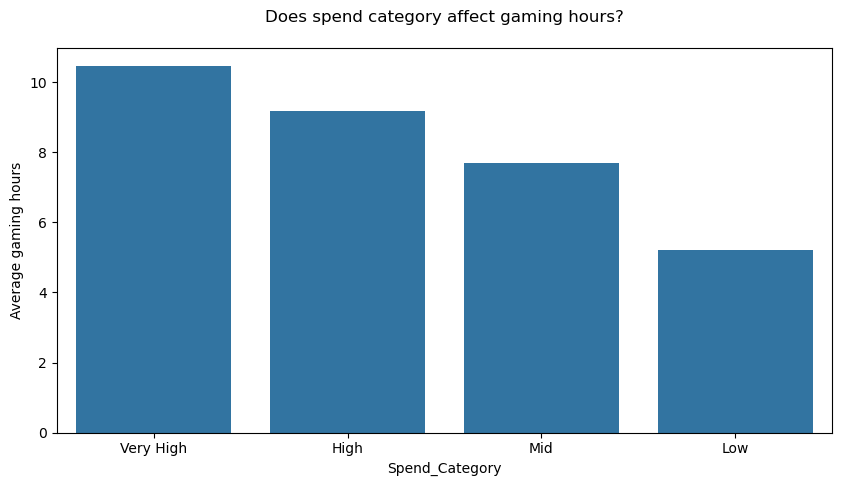

In [338]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=spending_analysis, 
    x="Spend_Category", 
    y="avg_gaming_hours"
)

plt.title("Does spend category affect gaming hours?\n")
plt.ylabel("Average gaming hours")
plt.show()

#### **11.10 Academic Work Preformance Analysis**

In [404]:
academic_work_performance_analysis = (
    fact_table.groupby("academic_work_performance")
    .agg(
        avg_daily_gaming_hours = ("daily_gaming_hours","mean")
    )
    .reset_index()
    .round(1)
    .sort_values(by="avg_daily_gaming_hours",ascending=False)
)
academic_work_performance_analysis

,academic_work_performance,avg_daily_gaming_hours
3,Failing,8.5
5,Poor,8.1
1,Below Average,6.9
0,Average,5.7
4,Good,4.3
2,Excellent,3.9


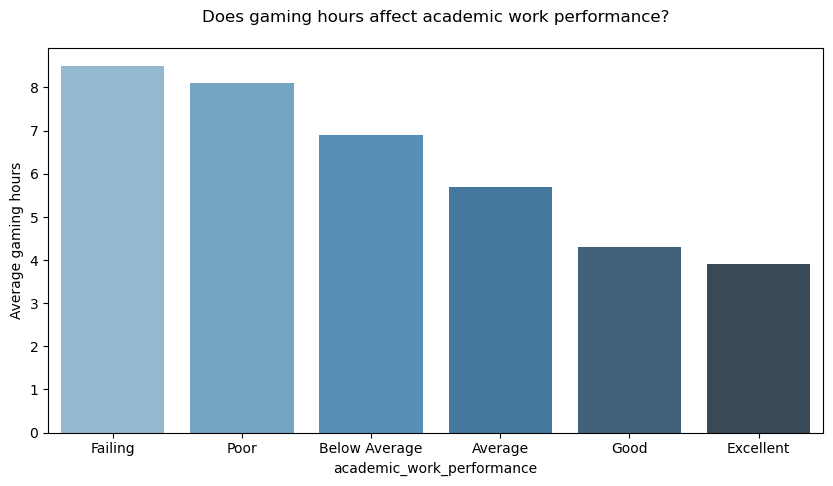

In [413]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=academic_work_performance_analysis, 
    x="academic_work_performance", 
    y="avg_daily_gaming_hours",
    palette="Blues_d",
    hue="academic_work_performance"
)

plt.title("Does gaming hours affect academic work performance?\n")
plt.ylabel("Average gaming hours")
plt.show()

#### **11.11 Work Productivity Score Analysis**

In [414]:
work_productivity_score_analysis = (
    fact_table.groupby("daily_gaming_hours")
    .agg(
        sum_work_productivity_score = ("work_productivity_score","sum")
    )
    .reset_index()
    .round(1)
)
work_productivity_score_analysis

,daily_gaming_hours,sum_work_productivity_score
0,0.5,8.0
1,0.6,24.0
2,0.7,24.0
3,0.8,9.0
4,0.9,2.0
...,...,...
127,13.9,5.0
128,14.1,2.0
129,14.2,7.0
130,14.7,10.0


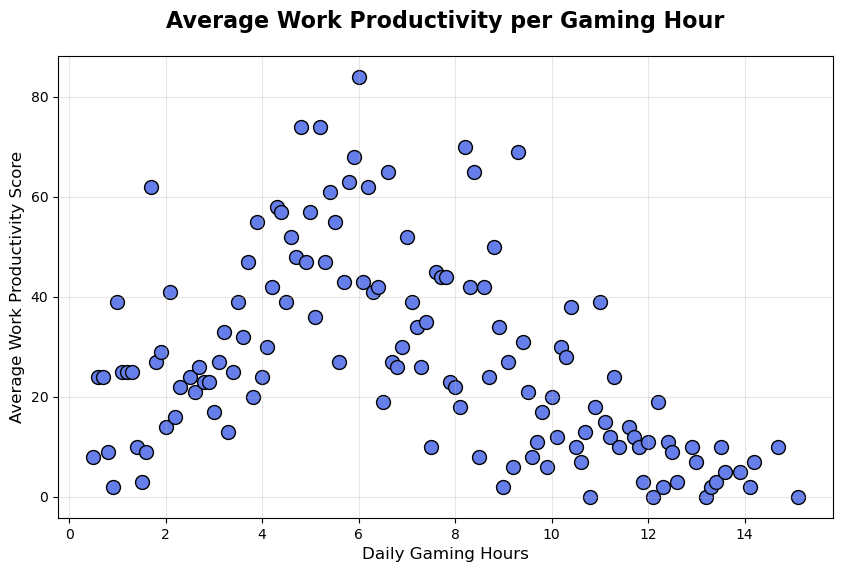

In [397]:
plt.figure(figsize=(10, 6))
plt.scatter(
    work_productivity_score_analysis['daily_gaming_hours'],
    work_productivity_score_analysis['sum_work_productivity_score'],
    c='#667eea', s=100, edgecolors='black', linewidth=1
)
plt.title('Average Work Productivity per Gaming Hour', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Gaming Hours', fontsize=12)
plt.ylabel('Average Work Productivity Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

#### **11.12 Pysical Analysis**

In [246]:
pysical_analysis = (
    fact_table.merge(dim_physical, on="physical_id", how="inner")
    .groupby("physical_pain")
    .agg(
        players=("record_id", "count"),
        sum_total_spent=("total_spent", "sum"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("sum_total_spent", ascending=True)
)
pysical_analysis

,physical_pain,players,sum_total_spent,avg_gaming_hours
1,Low_Risk,391,1410856.08,3.95
0,High_Risk,236,2535972.00,8.28
2,Moderate,373,3257770.44,7.12


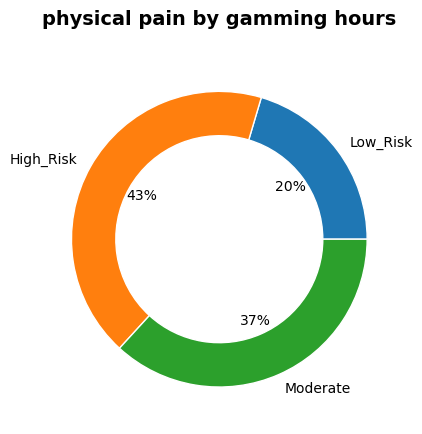

In [247]:
plt.pie(
    x=pysical_analysis["avg_gaming_hours"],       
    labels=pysical_analysis["physical_pain"], 
    autopct='%1.0f%%',
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}
)

plt.title("physical pain by gamming hours\n", fontsize=14, fontweight='bold')
plt.show()

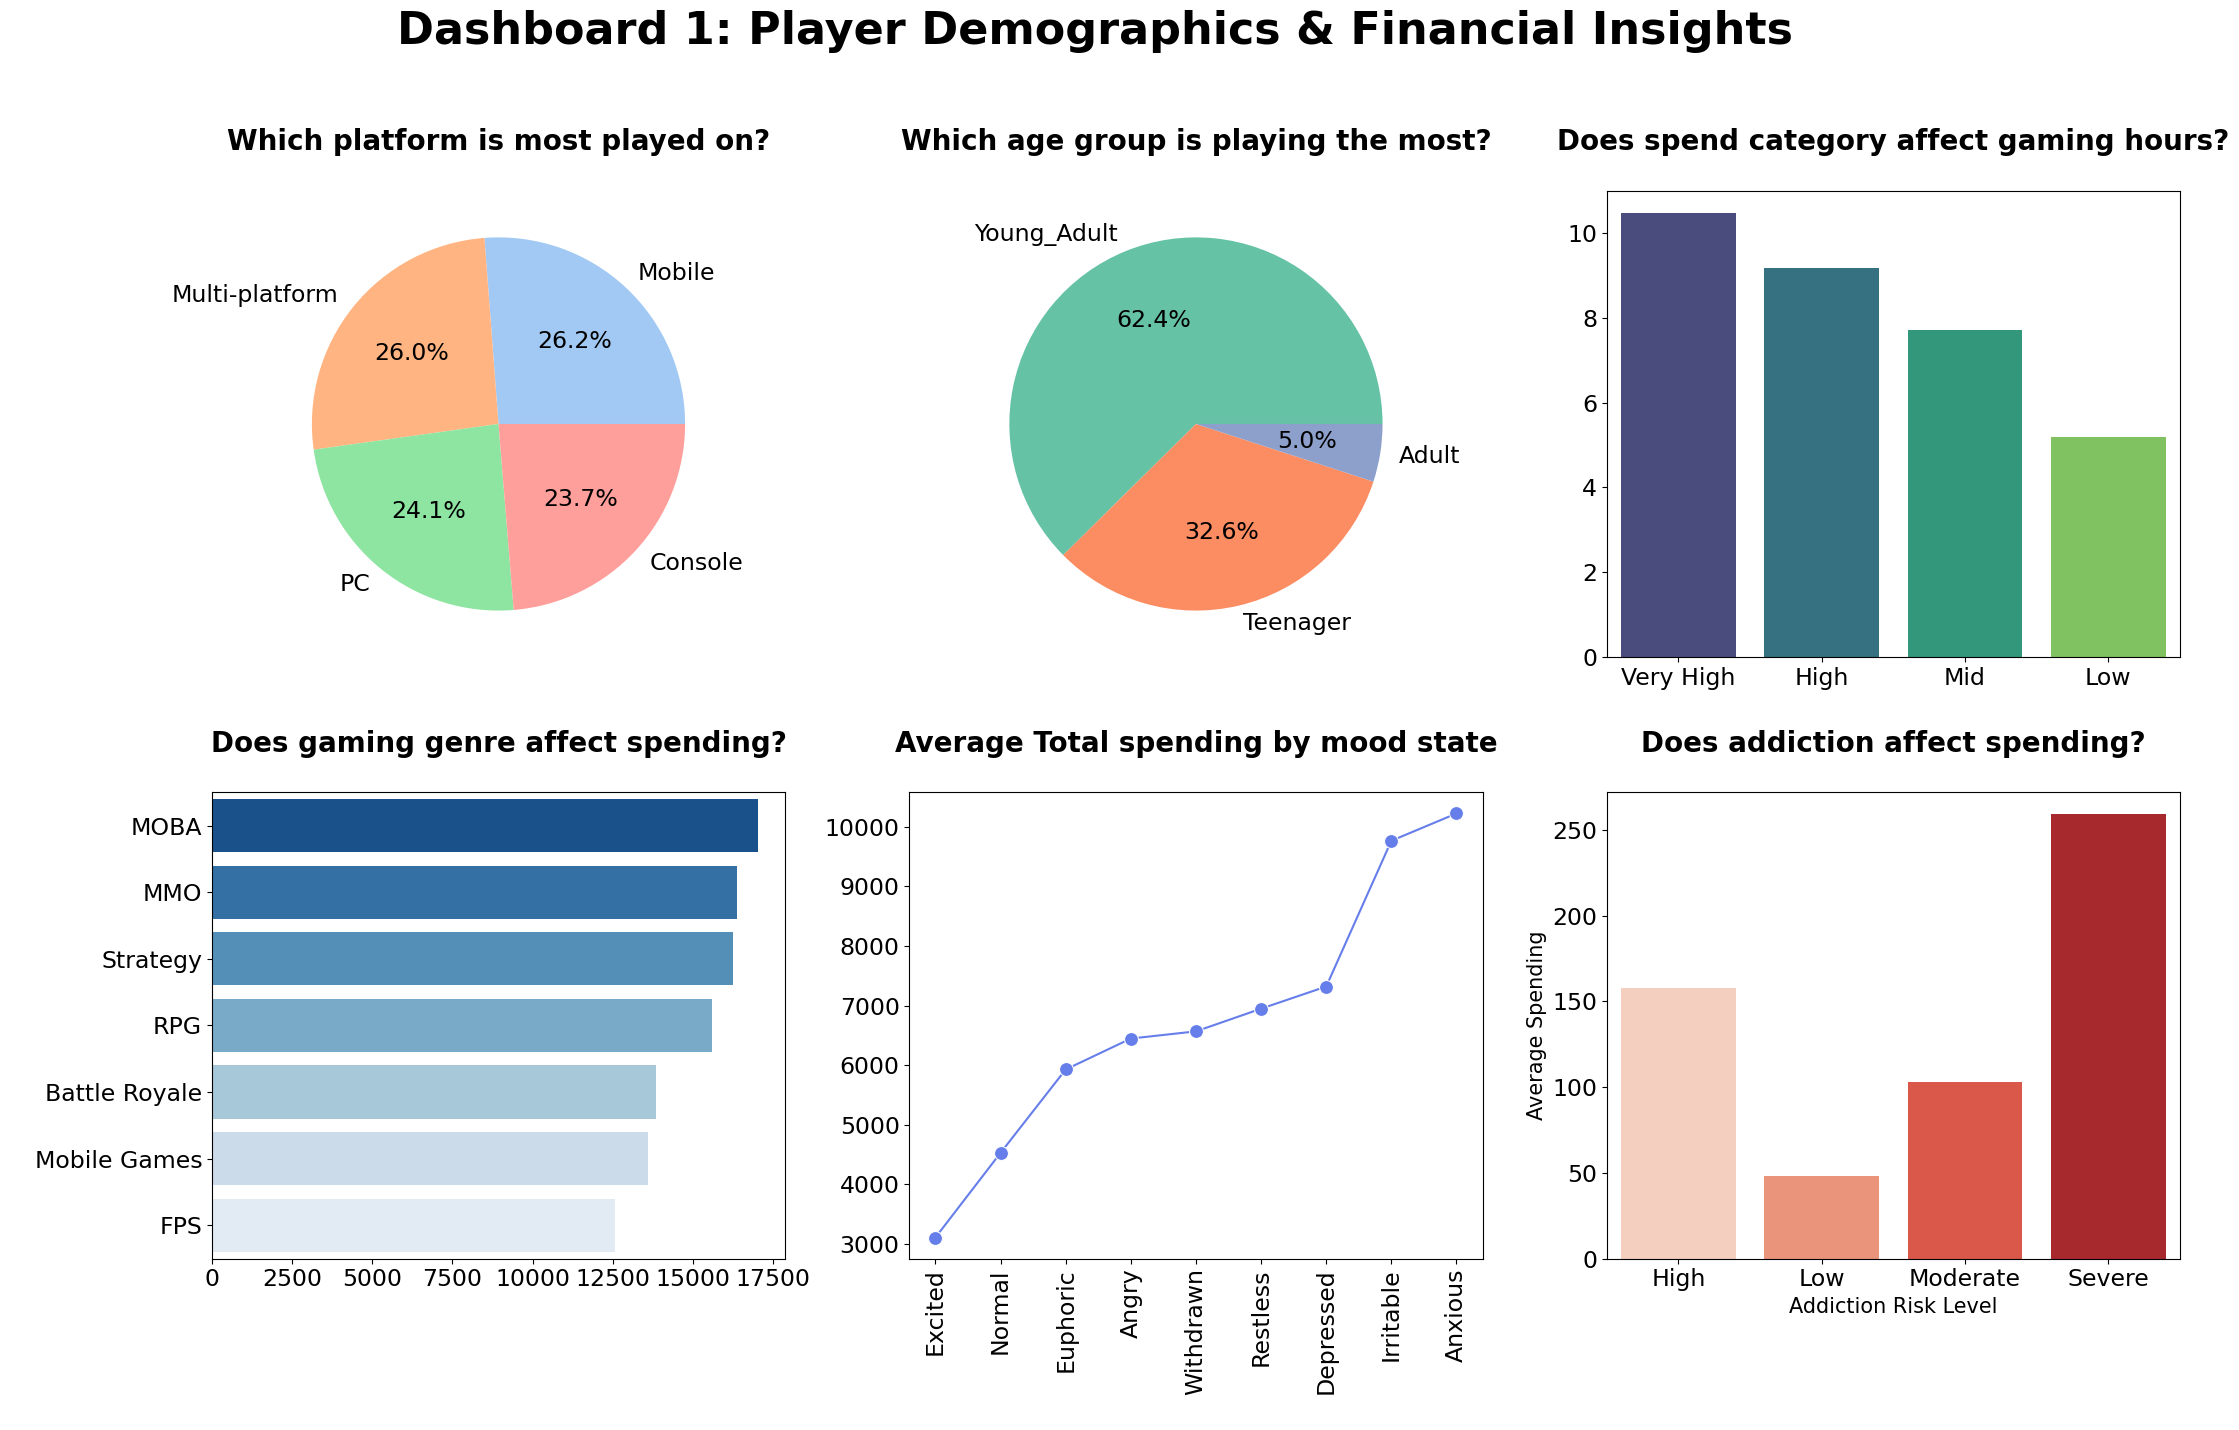

In [417]:
# [1] Set up the figure and axes (2 rows by 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 15))

# Main dashboard title 
fig.suptitle('Dashboard 1: Player Demographics & Financial Insights', fontsize=32, fontweight='bold')

# ==========================================
# Plot 1: Gaming platform usage distribution (Pie Chart)
# ==========================================
platform_counts = fact_gaming_mental_health['gaming_platform'].value_counts()
axes[0, 0].pie(
    x=platform_counts.values,        
    labels=platform_counts.index, 
    autopct='%1.1f%%',
    colors=sns.color_palette("pastel"),
    textprops={'fontsize': 17} 
)
axes[0, 0].set_title("Which platform is most played on?\n", fontsize=20, fontweight='bold')

# ==========================================
# Plot 2: Age group distribution (Pie Chart)
# ==========================================
age_counts = fact_gaming_mental_health['age_group'].value_counts()
axes[0, 1].pie(
    x=age_counts.values,        
    labels=age_counts.index, 
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2"),
    textprops={'fontsize': 17}
)
axes[0, 1].set_title("Which age group is playing the most?\n", fontsize=20, fontweight='bold')

# ==========================================
# Plot 3: Spend category vs. average gaming hours (Bar Chart)
# ==========================================
sns.barplot(data=spending_analysis, x="Spend_Category", y="avg_gaming_hours", hue="Spend_Category", legend=False, ax=axes[0, 2], palette="viridis")
axes[0, 2].set_title("Does spend category affect gaming hours?\n", fontsize=20, fontweight='bold')
axes[0, 2].set_ylabel(" ", fontsize=14) # Increase Y-axis label font size
axes[0, 2].set_xlabel(" ", fontsize=14)   # Increase X-axis label font size
axes[0, 2].tick_params(axis='both', labelsize=17)      # Increase tick labels font size on both axes

# ==========================================
# Plot 4: Game genres and their impact on total spending (Horizontal Bar Chart)
# ==========================================
# Sort game genres by total spending in descending order
sorted_genres = genre_addiction.sort_values(by="total_spending", ascending=False)
sns.barplot(data=sorted_genres, x="total_spending", y="game_genre", hue="game_genre", legend=False, ax=axes[1, 0], palette="Blues_r")
axes[1, 0].set_title("\nDoes gaming genre affect spending?\n", fontsize=20, fontweight='bold')
axes[1, 0].set_xlabel(" ", fontsize=14)
axes[1, 0].set_ylabel(" ", fontsize=14)
axes[1, 0].tick_params(axis='both', labelsize=17)

# ==========================================
# Plot 5: Mood state vs. average total spending (Line Chart)
# ==========================================
sns.lineplot(data=mood_state_analysis, x='mood_state', y='avg_total_spent', marker='o', markersize=10, color='#667eea', ax=axes[1, 1])
axes[1, 1].set_title("Average Total spending by mood state\n", fontsize=20, fontweight='bold')
axes[1, 1].set_ylabel(" ", fontsize=14)
axes[1, 1].set_xlabel(" ", fontsize=14)
axes[1, 1].tick_params(axis='both', labelsize=17)
axes[1, 1].tick_params(axis='x', rotation=90)

# ==========================================
# Plot 6: Addiction risk level vs. average spending (Bar Chart)
# ==========================================
sns.barplot(data=addiction_analysis, x="gaming_addiction_risk_level", y="avg_spending", hue="gaming_addiction_risk_level", legend=False, ax=axes[1, 2], palette="Reds")
axes[1, 2].set_title("Does addiction affect spending?\n", fontsize=20, fontweight='bold')
axes[1, 2].set_ylabel("Average Spending", fontsize=15)
axes[1, 2].set_xlabel("Addiction Risk Level", fontsize=15)
axes[1, 2].tick_params(axis='both', labelsize=17)

# ==========================================
# [2] Final layout adjustments
# ==========================================
# Ensure proper spacing between subplots so text/labels do not overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

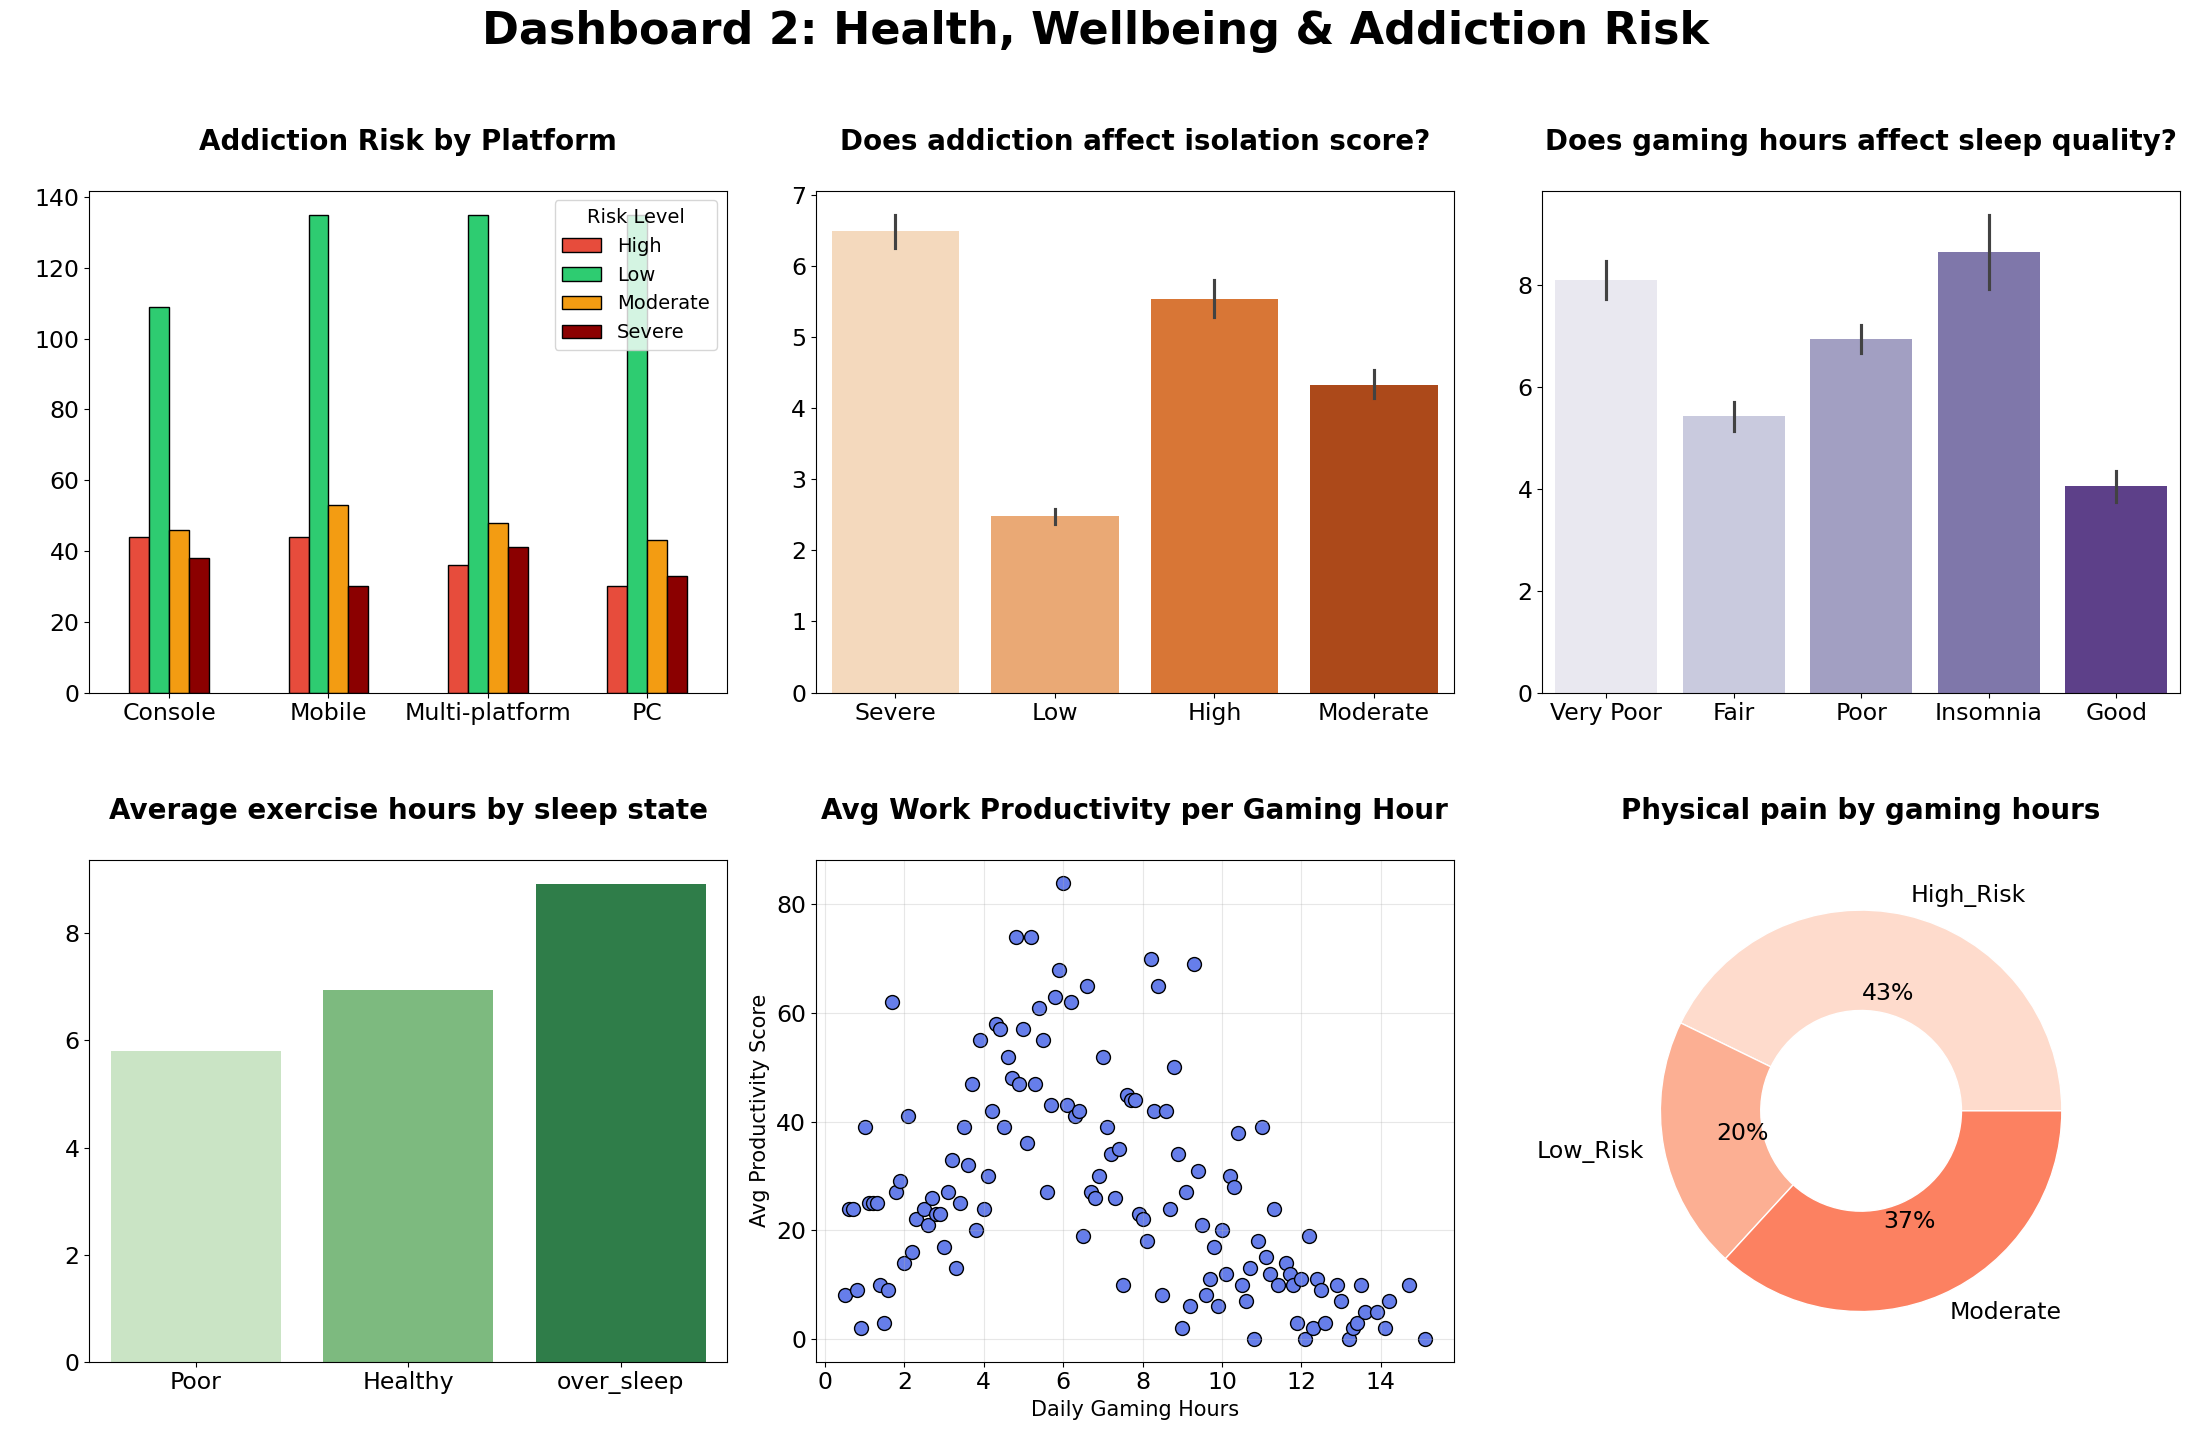

In [423]:
# [1] Set up the figure and axes (2 rows by 3 columns) with consistent size
fig, axes = plt.subplots(2, 3, figsize=(22, 15))

# Main dashboard title
fig.suptitle('Dashboard 2: Health, Wellbeing & Addiction Risk', fontsize=32, fontweight='bold')

# ==========================================
# Plot 1: Addiction Risk by Platform (Grouped Bar Chart)
# ==========================================
cross_tab = pd.crosstab(fact_gaming_mental_health["gaming_platform"], fact_gaming_mental_health["gaming_addiction_risk_level"])
custom_colors = ['#e74c3c','#2ecc71', '#f39c12',  '#8b0000']
cross_tab.plot(kind="bar", ax=axes[0, 0], color=custom_colors, edgecolor="black")

axes[0, 0].set_title("Addiction Risk by Platform\n", fontsize=20, fontweight='bold')
axes[0, 0].set_ylabel(" ", fontsize=14)
axes[0, 0].set_xlabel(" ", fontsize=14)
axes[0, 0].tick_params(axis='both', labelsize=17)
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(fontsize=14, title="Risk Level", title_fontsize=14) # ضفنا عنوان للـ Legend عشان الشياكة
# ==========================================
# Plot 2: Addiction vs Social Isolation (Bar Chart)
# ==========================================
sns.barplot(data=fact_gaming_mental_health, x="gaming_addiction_risk_level", y="social_isolation_score", hue="gaming_addiction_risk_level", legend=False, ax=axes[0, 1], palette="Oranges")
axes[0, 1].set_title("Does addiction affect isolation score?\n", fontsize=20, fontweight='bold')
axes[0, 1].set_ylabel(" ", fontsize=14)
axes[0, 1].set_xlabel(" ", fontsize=14)
axes[0, 1].tick_params(axis='both', labelsize=17)

# ==========================================
# Plot 3: Gaming Hours vs Sleep Quality (Bar Chart)
# ==========================================
sns.barplot(data=fact_gaming_mental_health, x="sleep_quality", y="daily_gaming_hours", hue="sleep_quality", legend=False, ax=axes[0, 2], palette="Purples")
axes[0, 2].set_title("Does gaming hours affect sleep quality?\n", fontsize=20, fontweight='bold')
axes[0, 2].set_ylabel(" ", fontsize=14)
axes[0, 2].set_xlabel(" ", fontsize=14)
axes[0, 2].tick_params(axis='both', labelsize=17)

# ==========================================
# Plot 4: Sleep State vs Sleep Hours (Bar Chart)
# ==========================================
sns.barplot(data=gaming_sleep_analysis, x="sleep_state", y="avg_exercise_hours", hue="sleep_state", legend=False, ax=axes[1, 0], palette="Greens")
axes[1, 0].set_title("\nAverage exercise hours by sleep state\n", fontsize=20, fontweight='bold')
axes[1, 0].set_ylabel(" ", fontsize=14)
axes[1, 0].set_xlabel(" ", fontsize=14)
axes[1, 0].tick_params(axis='both', labelsize=17)

# ==========================================
# Plot 5: Gaming Hours vs Productivity (Scatter Plot)
# ==========================================
temp_scatter = fact_gaming_mental_health.groupby('daily_gaming_hours')['work_productivity_score'].sum().reset_index()
axes[1, 1].scatter(temp_scatter['daily_gaming_hours'], temp_scatter['work_productivity_score'], c='#667eea', s=100, edgecolors='black')
axes[1, 1].set_title("\nAvg Work Productivity per Gaming Hour\n", fontsize=20, fontweight='bold')
axes[1, 1].set_ylabel("Avg Productivity Score", fontsize=15)
axes[1, 1].set_xlabel("Daily Gaming Hours", fontsize=15)
axes[1, 1].tick_params(axis='both', labelsize=17)
axes[1, 1].grid(True, alpha=0.3)

# ==========================================
# Plot 6: Physical Pain vs Gaming Hours (Donut Chart)
# ==========================================
temp_pie = fact_gaming_mental_health.groupby("physical_pain")["daily_gaming_hours"].mean()
axes[1, 2].pie(
    x=temp_pie.values,        
    labels=temp_pie.index, 
    autopct='%1.0f%%',
    wedgeprops={'width': 0.5, 'edgecolor': 'white'},
    colors=sns.color_palette("Reds"),
    textprops={'color': 'black', 'fontsize': 17} # Adjusted to 17 to match other labels, keeping your white color
)
axes[1, 2].set_title("\nPhysical pain by gaming hours\n", fontsize=20, fontweight='bold')

# ==========================================
# [2] Final layout adjustments
# ==========================================
# Ensure proper spacing between subplots so text/labels do not overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **12- Strategic Actionable Recommendations:**

1. Implement Strict Screen-Time Hard Limits
Gamers should leverage console and PC built-in digital well-being tools to enforce a maximum cap of 3 to 3.5 hours of daily gaming to protect academic performance and minimize dependency risks.

2. Adopt Sleep Hygiene & Ergonomic Break Protocols
Enforce a strict "No-Screen Buffer Hour" before bedtime to ensure better sleep quality, alongside practicing the 20-20-20 rule during active gaming sessions to reduce physical strain and eye fatigue.

3. Foster Offline Social Integration
Universities and local communities should create hybrid or physical social clubs that align with esports interests, directly helping high-risk gamers convert online screen time into real-world, face-to-face social connections.

4. Establish Automated Micro-transaction Caps
Players experiencing high impulse spending should set up automated, monthly micro-transaction boundaries directly inside their banking or payment applications to avoid gaming-induced financial stress.